In [1]:
import pandas as pd
import joblib

In [2]:
preprocess = joblib.load("preprocess_pipeline.pkl")

X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_val = pd.read_csv("y_val.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [4]:
# Recompute feature lists based on current X_train columns
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Patient ID in num?", "Patient ID" in num_cols)
print("Patient ID in cat?", "Patient ID" in cat_cols)

Patient ID in num? False
Patient ID in cat? False


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

In [6]:
model_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
model_lr.fit(X_train, y_train)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Neoplasm Disease Stage American Joint Committee on Cancer Code'
 'Cllularity based on allele frequency' 'BCL2 Fish Status'
 'BCL6 Fish Status' 'B Symptoms at Diagnosis' 'Censored'
 'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage'
 'Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage'
 'Neoplasm American Joint Committee on Cancer Clinical Primary Tumor T Stage'
 'CNS Relapse' 'CNS Status' 'Days to Sample Procurement' 'Disease code'
 'Estimated Tumor Cellularity' 'Neoplasm Histologic Grade'
 'Prior immunosuppressive therapy other' 'Igk genotype results'
 'Initial pathologic diagnosis method' 'Initial Treatment Response'
 'AnnArbor Stage IPI' 'Extranodal IPI Factor'
 'First Pathologic Diagnosis Biospecimen Acquisition Method Type'
 'MYC Fish Status' 'Normal Genome Coverage' 'Normal Genome Li

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

class SafeNumeric(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            Xc = X.copy()
            for c in Xc.columns:
                Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
            return Xc.values
        X = np.array(X, dtype=object)
        out = np.empty(X.shape, dtype=float)
        out[:] = np.nan
        for i in range(X.shape[1]):
            out[:, i] = pd.to_numeric(pd.Series(X[:, i]), errors="coerce").values
        return out

# IMPORTANT: recompute cols from CURRENT X_train
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("to_numeric", SafeNumeric()),              # ✅ makes median safe
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

print("Preprocess rebuilt ✅")

Preprocess rebuilt ✅


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model_rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    ))
])

model_rf.fit(X_train, y_train)
print("RandomForest fitted ✅")

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


RandomForest fitted ✅


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

In [10]:
#Evaluation utilities (AUC, F1, Brier, ECE, calibration plot)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    # ECE = sum_k |acc(k) - conf(k)| * (n_k / N)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    N = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += np.abs(acc - conf) * (mask.sum() / N)
    return float(ece)

In [11]:
def evaluate_model(model, X, y, name="model"):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob),
        "brier": brier_score_loss(y, prob),
        "ece_10bins": expected_calibration_error(y, prob, n_bins=10),
    }


In [12]:
def plot_calibration(model, X, y, title):
    prob = model.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, prob, n_bins=10, strategy="uniform")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.show()

In [13]:
#XGBoost

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline


In [14]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)

hgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("to_dense", to_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.05,
        random_state=42
    ))
])

In [15]:
hgb.fit(X_train, y_train)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,steps,"[('preprocess', ...), ('to_dense', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
#MLP (Neural Network for tabular)

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline


In [17]:
mlp = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,             # L2 regularization
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    ))
])

In [18]:
mlp.fit(X_train, y_train)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
#Compare models on Validation (performance + reliability)

results = []

results.append(evaluate_model(model_rf, X_val, y_val, "RandomForest"))

if 'xgb' in globals():
    results.append(evaluate_model(xgb, X_val, y_val, "XGBoost"))
if 'hgb' in globals():
    results.append(evaluate_model(hgb, X_val, y_val, "HistGB (fallback)"))

results.append(evaluate_model(mlp, X_val, y_val, "MLP"))

pd.DataFrame(results).sort_values(by=["roc_auc", "f1"], ascending=False)

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 9

,model,accuracy,precision,recall,f1,roc_auc,brier,ece_10bins
0,RandomForest,0.763514,0.685714,0.500000,0.578313,0.863854,0.140591,0.074696
1,HistGB (fallback),0.743243,0.613636,0.562500,0.586957,0.831875,0.191843,0.172589
2,MLP,0.777027,0.941176,0.333333,0.492308,0.806250,0.163381,0.110644


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


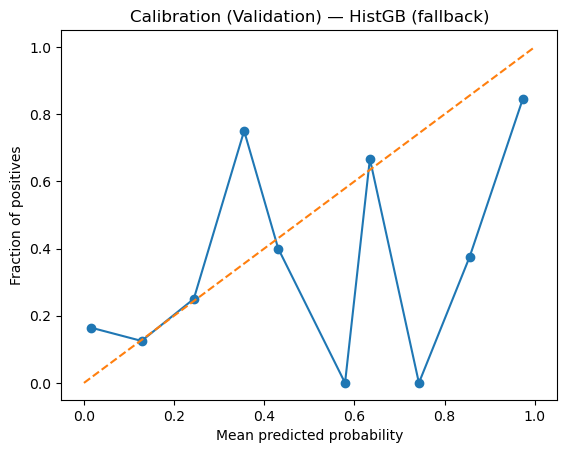

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


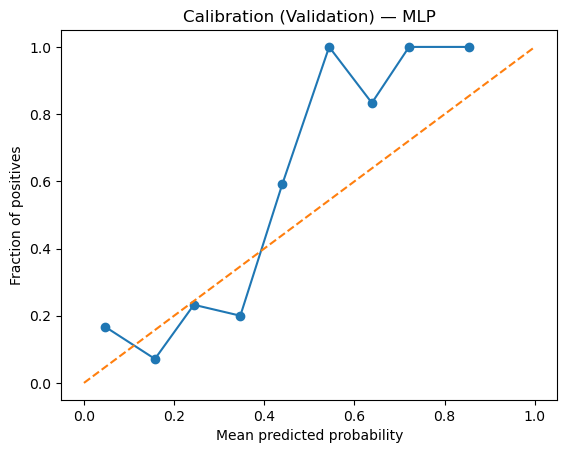

In [20]:
if 'xgb' in globals():
    plot_calibration(xgb, X_val, y_val, "Calibration (Validation) — XGBoost")
if 'hgb' in globals():
    plot_calibration(hgb, X_val, y_val, "Calibration (Validation) — HistGB (fallback)")

plot_calibration(mlp, X_val, y_val, "Calibration (Validation) — MLP")

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


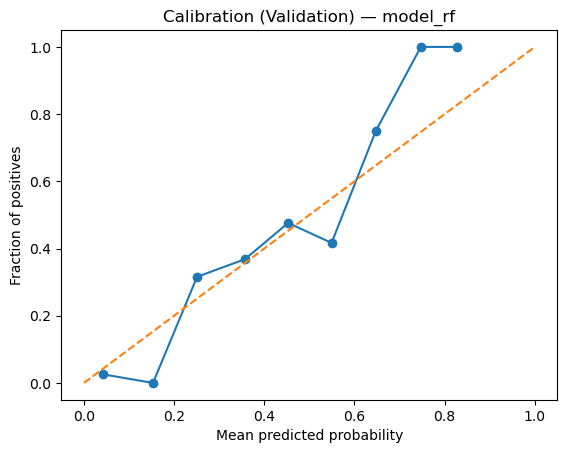

In [21]:

plot_calibration(model_rf, X_val, y_val, "Calibration (Validation) — model_rf")

In [22]:
best_model = model_rf
test_res = evaluate_model(best_model, X_test, y_test, "BEST — Test")
test_res

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


{'model': 'BEST — Test',
 'accuracy': 0.7891891891891892,
 'precision': 0.7692307692307693,
 'recall': 0.5,
 'f1': 0.6060606060606061,
 'roc_auc': 0.875,
 'brier': 0.13830385135135131,
 'ece_10bins': 0.0555135135135135}

In [23]:
import joblib
joblib.dump(best_model, "best_model.pkl")
print("Saved: best_model.pkl")

Saved: best_model.pkl


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

rf_tune = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best params: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}
Best CV ROC-AUC: 0.8544692427270709


In [25]:
import joblib

best_model = search.best_estimator_
joblib.dump(best_model, "best_model_tuned.pkl")

['best_model_tuned.pkl']

In [26]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", np.mean(cv_scores))
print("Std CV ROC-AUC:", np.std(cv_scores))

CV ROC-AUC scores: [0.83552632 0.83966245 0.90295359 0.8550966  0.83910726]
Mean CV ROC-AUC: 0.8544692427270709
Std CV ROC-AUC: 0.025160251593110434


In [27]:
# stratifield k fold

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc"
)

print("Stratified 5-Fold ROC-AUC scores:", scores)
print("Mean ROC-AUC:", np.mean(scores))
print("Std ROC-AUC:", np.std(scores))

C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 23 25 27 29 31 32 34 37 40 46 52
 54 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 9

Stratified 5-Fold ROC-AUC scores: [0.83355263 0.87893541 0.84972412 0.82711526 0.92804797]
Mean ROC-AUC: 0.8634750764447633
Std ROC-AUC: 0.036919258923369475


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

probs = model_rf.predict_proba(X_test)[:,1]

thresholds = [0.3,0.4,0.5]

for t in thresholds:
    preds = (probs >= t).astype(int)
    
    print(
        t,
        precision_score(y_test,preds),
        recall_score(y_test,preds),
        f1_score(y_test,preds)
    )

0.3 0.6153846153846154 0.8 0.6956521739130435
0.4 0.6666666666666666 0.6333333333333333 0.6495726495726496
0.5 0.7692307692307693 0.5 0.6060606060606061


C:\Users\WASIF FAIZ\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: [ 2  3  5  6  7  8  9 10 11 13 14 17 20 25 27 29 31 32 34 37 40 46 52 54
 55 56 62 63 64 65 66 68 69 70 71 79 80 82 84 85 89 90 94]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
